In [44]:
#!pip install -r requirements.txt

In [45]:
import os
from shutil import move
from torchvision.transforms import RandomErasing, ColorJitter
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from kagglehub import kagglehub
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm import tqdm


In [46]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")


CUDA is available!
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


In [47]:
def create_dataloaders(train_dataset, test_dataset, batch_size, val_split=0.2, num_workers=4):
    # Split train_dataset into training and validation datasets
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Extract labels for the training subset
    train_labels = [train_dataset.targets[i] for i in train_subset.indices]

    # Calculate class counts and weights
    class_counts = np.bincount(train_labels)
    class_weights = 1. / (np.sqrt(class_counts + 1e-6))  # Normalize weights to avoid division errors
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    # Log class weights for debugging
    print(f"Class counts: {class_counts}")
    print(f"Class weights: {class_weights}")

    # Create sample weights for WeightedRandomSampler
    sample_weights = torch.tensor([class_weights[label] for label in train_labels], dtype=torch.float32)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # Create DataLoaders
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  # Ensure deterministic test set order
        num_workers=num_workers,
        pin_memory=True
    )

    # Log dataset sizes for verification
    print(f"Train size: {len(train_subset)}, Validation size: {len(val_subset)}, Test size: {len(test_dataset)}")

    return train_loader, val_loader, test_loader


In [48]:
def compute_dataset_stats(dataset):
    """
    Computes the mean and standard deviation of a grayscale dataset.

    Args:
        dataset (torch.utils.data.Dataset): Dataset for which to compute statistics.

    Returns:
        tuple: Mean and standard deviation for the single channel.
    """
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    mean = 0.0
    std = 0.0
    total_samples = 0

    for images, _ in loader:
        batch_samples = images.size(0)  # Batch size
        images = images.view(batch_samples, -1)  # Flatten all pixels into one dimension
        mean += images.mean(1).sum(0)
        std += images.std(1).sum(0)
        total_samples += batch_samples

    mean /= total_samples
    std /= total_samples

    return mean.item(), std.item()


In [49]:
def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy()

    images = images * 0.5 + 0.5

    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()


In [50]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=100, log_interval=100, patience=5):
    """
    Trains a given model with streamlined logging and early stopping, while logging to TensorBoard.

    Args:
        model: The model to train.
        train_loader: DataLoader for the training dataset.
        val_loader: DataLoader for the validation dataset.
        optimizer: Optimizer for training (e.g., Adam, SGD).
        criterion: Loss function (e.g., CrossEntropyLoss).
        num_epochs: Number of training epochs.
        log_interval: Frequency (in batches) to log metrics during training.
        patience: Number of epochs to wait for validation loss improvement before stopping.
    """
    # Initialize TensorBoard writer
    writer = SummaryWriter(log_dir="../logs")

    # Set device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0
    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Optimizer step
            optimizer.step()

            # Accumulate loss
            running_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

            # Log batch loss and accuracy to TensorBoard periodically
            if (batch_idx + 1) % log_interval == 0:
                avg_loss = running_loss / log_interval
                writer.add_scalar("Batch Training Loss", avg_loss, epoch * len(train_loader) + batch_idx)
                running_loss = 0.0

        # Training accuracy for the epoch
        train_accuracy = correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Validation accuracy
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss /= len(val_loader)
        val_accuracy = correct_val / total_val

        # Log epoch metrics to TensorBoard
        writer.add_scalar("Epoch Training Accuracy", train_accuracy, epoch)
        writer.add_scalar("Epoch Validation Accuracy", val_accuracy, epoch)
        writer.add_scalar("Epoch Validation Loss", val_loss, epoch)

        # Epoch summary
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}, Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    writer.close()

In [51]:
def evaluate_model(model, data_loader):
    # Set the device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to the device
    model = model.to(device)

    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            # Move data to the same device as model
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


In [52]:
class CNN(nn.Module):
    def __init__(self, input_size=(48, 48), num_classes=8, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # Batch Norm
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Compute fully connected input size dynamically
        fc_input_size = 128 * (input_size[0] // 8) * (input_size[1] // 8)

        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(fc_input_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self._init_weights()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)


In [53]:
# Generalized permanent dataset path
home_dir = os.path.expanduser("~")  # Gets the user's home directory
permanent_path = os.path.join(home_dir, "datasets")

# Download dataset if it doesn't exist
if not os.path.exists(permanent_path):
    print("Downloading dataset...")
    temp_path = kagglehub.dataset_download("subhaditya/fer2013plus")  # Temporary download path
    print("Moving dataset to permanent location...")
    move(temp_path, permanent_path)
    print("Dataset moved to:", permanent_path)
else:
    print("Dataset already exists at:", permanent_path)

# Identify train and test directories dynamically
train_dir = os.path.join(permanent_path, "fer2013plus", "fer2013", "train")
test_dir = os.path.join(permanent_path, "fer2013plus", "fer2013", "test")

Dataset already exists at: /home/omarhammad/datasets


In [54]:
# Paths for augmented datasets
augmented_train_dir = os.path.join(permanent_path, "fer2013plus/fer2013/train_augmented")
augmented_test_dir = os.path.join(permanent_path, "fer2013plus/fer2013/test_augmented")

# Define augmentations for train and processing for test

# Compute stats for grayscale normalization
train_stats = compute_dataset_stats(datasets.ImageFolder(train_dir, transform=transforms.ToTensor()))
mean, std = train_stats
print(f"Computed Mean: {mean}, Std: {std}")

train_augment_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure grayscale
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(48, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Brightness/Contrast
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),  # Use single-channel stats
    transforms.RandomErasing(p=0.5),  # Add random erasing
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),  # Use single-channel stats
])


# Check if the augmented datasets exist
if not os.path.exists(augmented_train_dir) or not os.path.exists(augmented_test_dir):
    print("Augmented datasets not found. Creating augmented datasets...")

    # Use GPU for processing if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Create and save the augmented train dataset
    print("Processing train dataset...")
    for label in os.listdir(train_dir):
        label_dir = os.path.join(train_dir, label)
        save_dir = os.path.join(augmented_train_dir, label)
        os.makedirs(save_dir, exist_ok=True)
        for img_name in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
            img_path = os.path.join(label_dir, img_name)
            img = Image.open(img_path).convert("L")  # Convert to grayscale (1 channel)

            # Apply augmentations to the PIL Image
            for i in range(5):  # Generate 5 augmented images per original
                augmented_img = train_augment_transform(img)  # Apply transforms directly to the PIL Image
                augmented_img_pil = transforms.ToPILImage()(augmented_img)  # Convert tensor back to PIL Image for saving
                augmented_img_pil.save(os.path.join(save_dir, f"{os.path.splitext(img_name)[0]}_aug_{i}.png"))

    # Process and save the test dataset
    print("Processing test dataset...")
    for label in os.listdir(test_dir):
        label_dir = os.path.join(test_dir, label)
        save_dir = os.path.join(augmented_test_dir, label)
        os.makedirs(save_dir, exist_ok=True)
        for img_name in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
            img_path = os.path.join(label_dir, img_name)
            img = Image.open(img_path).convert("L")  # Convert to grayscale (1 channel)

            # Apply test transforms directly
            processed_img = test_transform(img)
            processed_img_pil = transforms.ToPILImage()(processed_img)  # Convert tensor back to PIL Image for saving
            processed_img_pil.save(os.path.join(save_dir, img_name))
else:
    print("Augmented datasets already exist. Skipping processing.")

# Reload processed datasets with normalization applied during loading
train_dataset = datasets.ImageFolder(augmented_train_dir, transform=train_augment_transform)
test_dataset = datasets.ImageFolder(augmented_test_dir, transform=test_transform)


Computed Mean: 0.5076549053192139, Std: 0.21201835572719574
Augmented datasets already exist. Skipping processing.


In [55]:
# Dataset sizes
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 141930
Test dataset size: 7099


In [56]:
train_loader, val_loader, test_loader = create_dataloaders(train_dataset, test_dataset, 16)
# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Class counts: [ 9863   665   754  2626 30267 41162 14024 14183]
Class weights: tensor([0.0101, 0.0388, 0.0364, 0.0195, 0.0057, 0.0049, 0.0084, 0.0084])
Train size: 113544, Validation size: 28386, Test size: 7099
Image batch shape: torch.Size([16, 1, 48, 48])
Labels batch shape: torch.Size([16])
Labels: tensor([7, 3, 7, 4, 3, 1, 5, 6, 5, 4, 4, 5, 4, 0, 3, 3])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


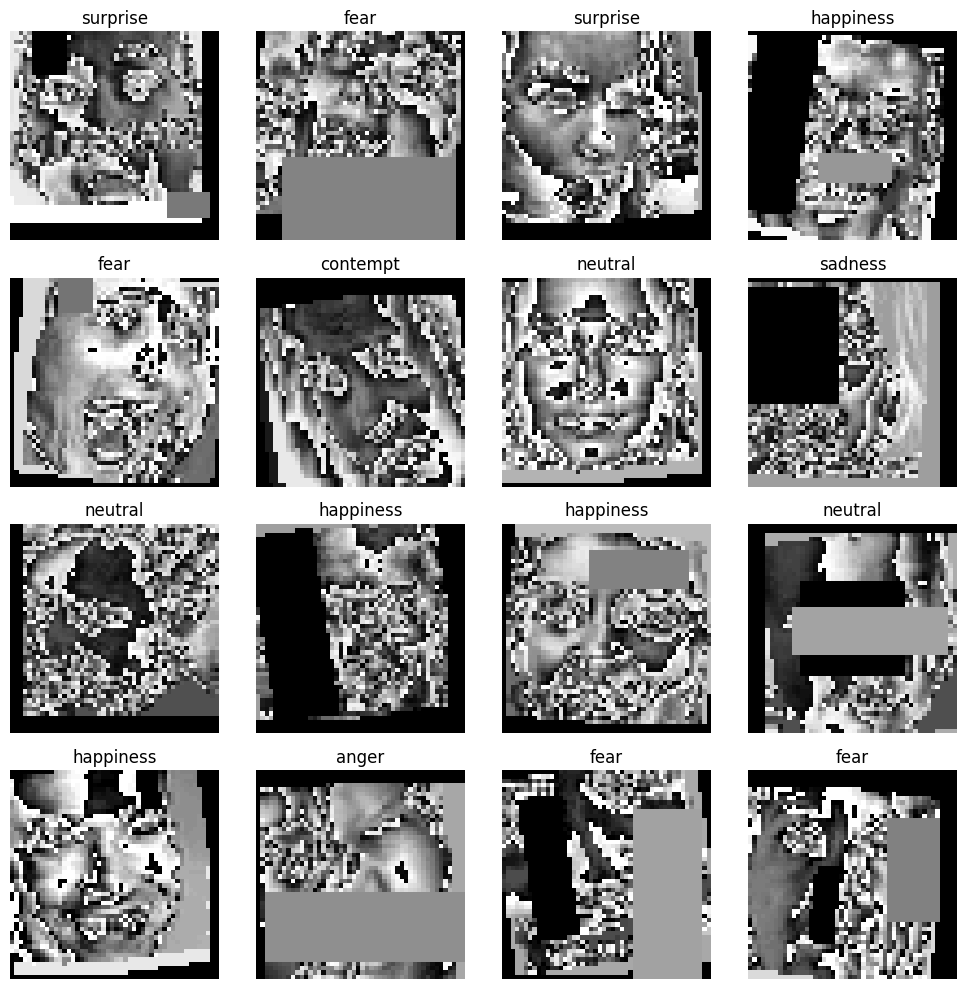

In [57]:
plot_image_batch(images, labels, class_names)


In [58]:
cnn_model = CNN()
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

In [59]:
train_model(cnn_model, train_loader, val_loader, optimizer, criterion, num_epochs=100, patience=4)
# tensorboard --logdir=../logs

Epoch [1/100], Train Acc: 0.2551, Val Acc: 0.4022, Val Loss: 1.6317
Epoch [2/100], Train Acc: 0.2824, Val Acc: 0.4183, Val Loss: 1.6303
Epoch [3/100], Train Acc: 0.2959, Val Acc: 0.4376, Val Loss: 1.5982
Epoch [4/100], Train Acc: 0.3362, Val Acc: 0.4790, Val Loss: 1.4780
Epoch [5/100], Train Acc: 0.3732, Val Acc: 0.4701, Val Loss: 1.4640
Epoch [6/100], Train Acc: 0.3898, Val Acc: 0.5063, Val Loss: 1.3918
Epoch [7/100], Train Acc: 0.4027, Val Acc: 0.5013, Val Loss: 1.3945
Epoch [8/100], Train Acc: 0.4171, Val Acc: 0.4964, Val Loss: 1.3931
Epoch [9/100], Train Acc: 0.4252, Val Acc: 0.5238, Val Loss: 1.3269
Epoch [10/100], Train Acc: 0.4376, Val Acc: 0.5332, Val Loss: 1.2925
Epoch [11/100], Train Acc: 0.4451, Val Acc: 0.5392, Val Loss: 1.2750
Epoch [12/100], Train Acc: 0.4511, Val Acc: 0.5434, Val Loss: 1.2745
Epoch [13/100], Train Acc: 0.4537, Val Acc: 0.5394, Val Loss: 1.2856
Epoch [14/100], Train Acc: 0.4648, Val Acc: 0.5325, Val Loss: 1.3060
Epoch [15/100], Train Acc: 0.4656, Val Acc:

In [60]:
train_accuracy = evaluate_model(cnn_model, train_loader)
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.5120


In [61]:
test_accuracy = evaluate_model(cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.6076


In [62]:
torch.save(cnn_model.state_dict(), 'initial_cnn_model.pth')